# 02 履约指标诊断：超时集中在哪里，哪些特征与超时相关

诊断问题：在可执行的即时单、已知商圈样本中，超时是否集中于特定日期、用餐高峰、商圈和履约阶段？

本 Notebook 只陈述分布、差异和相关性，不把描述性分解写成因果结论。

## 管理摘要

- 策略样本 **436,062 单**，超时 **59,456 单**，超时率 **13.63%**。
- 午晚高峰承载 **71.70%** 的订单，却集中了 **77.33%** 的超时；高峰超时率 **14.71%**，非高峰 **10.92%**。
- 超时订单平均超时 **4.60 分钟**，P50 为 **3.17 分钟**，P90 为 **9.17 分钟**；其中 **91.14%** 不超过 10 分钟。
- `da_id` 5、9、7、2、1 五个商圈以 **48.52%** 的订单贡献约 **59.62%** 的超时订单，问题高度集中；但商圈编号已匿名，不能映射为真实地名。
- 超时单比准时单的平均总履约时长长 **17.32 分钟**。差异中取餐后至送达阶段占 **57.11%**，接单至取餐阶段占 **28.54%**，进入配送至接单占 **10.45%**，下单至进入配送占 **3.91%**。
- 距离分位越高、派单尝试越多，超时率呈单调上升：距离最低十分位约 **5.82%**，最高十分位约 **20.36%**；一次派单约 **12.87%**，4 次及以上约 **29.12%**。
- 以上是关联证据。尤其“接单至取餐”同时包含去店路程和到店等待，不能直接归因于商家。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MART = PROJECT_ROOT / "data" / "processed" / "order_fulfillment_mart.parquet"
METRICS = PROJECT_ROOT / "outputs" / "metrics"

orders = pd.read_parquet(MART)
strategy = orders.loc[orders["is_strategy_eligible"]].copy()
daily = pd.read_csv(METRICS / "daily_kpi.csv")
time_of_day = pd.read_csv(METRICS / "time_of_day_kpi.csv")
district = pd.read_csv(METRICS / "district_kpi.csv")
meal_period = pd.read_csv(METRICS / "meal_period_kpi.csv")
stage_gap = pd.read_csv(METRICS / "late_vs_on_time_stage_gap.csv")

assert len(strategy) == 436_062
assert int(strategy["is_late"].sum()) == 59_456

## 1. 指标框架

```text
超时订单数 = 有效订单数 × 超时率
超时率 <- 时间结构 + 商圈结构 + 订单复杂度 + 派单摩擦 + 各履约阶段时长
总履约时长 = 下单至进入配送 + 进入配送至接单 + 接单至取餐 + 取餐至送达
是否超时 = 总履约时长是否超过平台承诺时长
```

诊断同时看超时率和超时订单数：只看超时率会把稀疏小单元排到前面，只看数量又会忽视局部严重问题。

## 2. 日期维度：短周期经营波动

In [2]:
daily_view = daily[["dt", "orders", "late_orders", "late_rate", "on_time_rate"]].copy()
daily_view["late_rate_pct"] = daily_view["late_rate"] * 100
daily_view

,dt,orders,late_orders,late_rate,on_time_rate,late_rate_pct
0,20221017,51517,6246,0.1212,0.8788,12.1242
1,20221018,52939,7509,0.1418,0.8582,14.1842
2,20221019,52620,7084,0.1346,0.8654,13.4626
3,20221020,52547,6976,0.1328,0.8672,13.2757
4,20221021,55073,8048,0.1461,0.8539,14.6133
5,20221022,59531,8176,0.1373,0.8627,13.7340
6,20221023,59898,8933,0.1491,0.8509,14.9137
7,20221024,51937,6484,0.1248,0.8752,12.4844


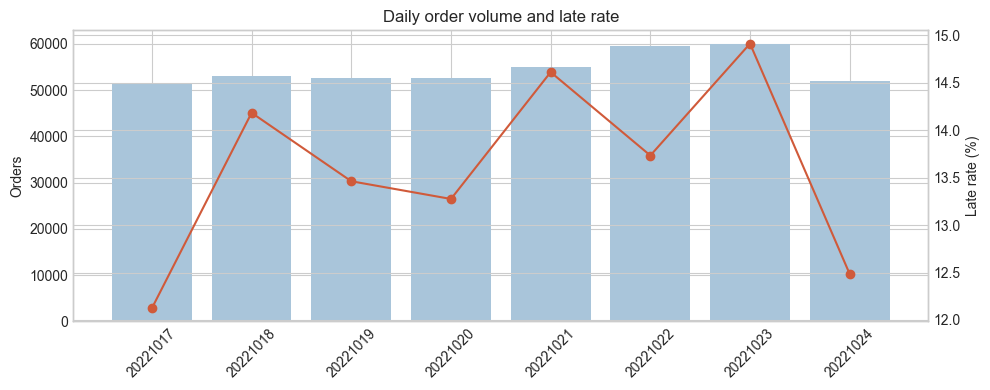

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(daily_view["dt"].astype(str), daily_view["orders"], color="#A9C5DA", label="Orders")
ax2.plot(
    daily_view["dt"].astype(str), daily_view["late_rate_pct"],
    color="#D05A3A", marker="o", label="Late rate"
)
ax1.set_ylabel("Orders")
ax2.set_ylabel("Late rate (%)")
ax1.set_title("Daily order volume and late rate")
ax1.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

8 天内超时率范围约为 12.12%–14.91%，10 月 23 日最高。但样本只有 8 天，不能把某一天的差异解释为稳定周规律或季节性。

## 3. 超时严重程度：以轻度超时为主

In [4]:
late_orders = strategy.loc[strategy["is_late"]].copy()
severity_summary = pd.DataFrame(
    {
        "metric": ["mean", "p50", "p90"],
        "late_minutes": [
            late_orders["late_minutes"].mean(),
            late_orders["late_minutes"].median(),
            late_orders["late_minutes"].quantile(0.9),
        ],
    }
)
severity_distribution = (
    late_orders["late_severity"]
    .value_counts(normalize=True)
    .rename("share")
    .mul(100)
    .reset_index()
)
display(severity_summary)
display(severity_distribution)

,metric,late_minutes
0,mean,4.5960
1,p50,3.1667
2,p90,9.1667


,late_severity,share
0,late_0_10m,91.1447
1,late_10_30m,8.1607
2,late_30m_plus,0.6946
3,on_time,0.0000


超时订单以 10 分钟以内的轻度超时为主，但仍存在少量严重长尾。后续策略评估不能只看超时率，还应同步监控 P90 超时分钟数，避免总体比例改善但严重超时恶化。

## 4. 时段维度：午晚高峰风险集中度

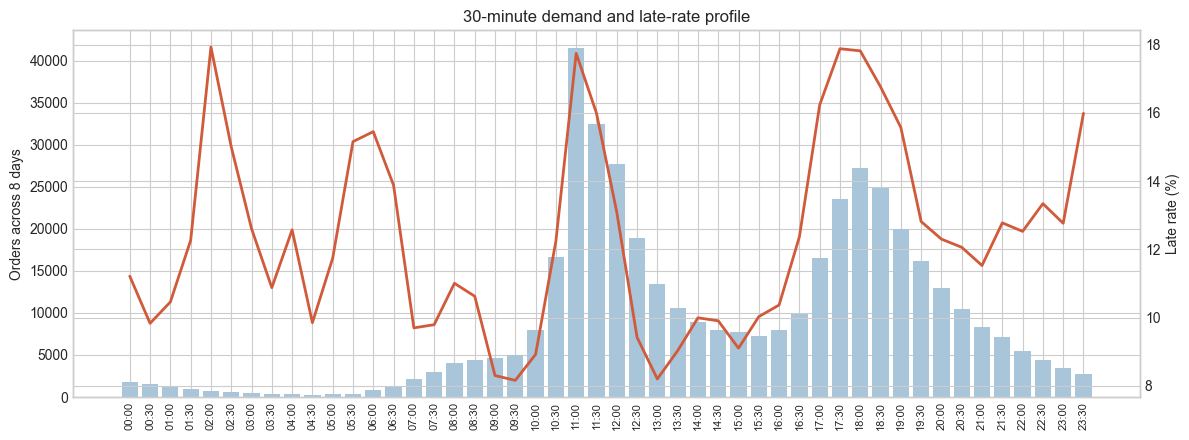

In [5]:
time_view = time_of_day.sort_values("time_of_day")
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()
ax1.bar(time_view["time_of_day"], time_view["orders"], color="#A9C5DA", label="Orders")
ax2.plot(
    time_view["time_of_day"], time_view["late_rate"] * 100,
    color="#D05A3A", linewidth=2, label="Late rate"
)
ax1.set_ylabel("Orders across 8 days")
ax2.set_ylabel("Late rate (%)")
ax1.set_title("30-minute demand and late-rate profile")
ax1.tick_params(axis="x", rotation=90, labelsize=8)
fig.tight_layout()
plt.show()

In [6]:
meal_view = meal_period[["meal_period", "orders", "late_orders", "late_rate"]].copy()
meal_view["late_rate_pct"] = meal_view["late_rate"] * 100
meal_view

,meal_period,orders,late_orders,late_rate,late_rate_pct
0,off_morning,42209,4295,0.1018,10.1756
1,lunch,161133,22054,0.1369,13.6868
2,off_afternoon,49680,5159,0.1038,10.3845
3,dinner,151524,23924,0.1579,15.7889
4,off_night,31516,4024,0.1277,12.7681


项目把午高峰定义为 [10:30, 14:00)、晚高峰定义为 [17:00, 21:00)，以订单首次进入配送系统的时点计。这是根据样本内订单量峰值形成的分析口径，不是官方排班标准。

## 5. 商圈维度：超时规模与服务水平联合评估

In [7]:
district_view = district.sort_values("late_orders", ascending=False).copy()
district_view["late_rate_pct"] = district_view["late_rate"] * 100
district_view["cumulative_late_share_pct"] = district_view["late_order_contribution"].cumsum() * 100
district_view[
    ["da_id", "orders", "late_orders", "late_rate_pct", "late_order_contribution", "cumulative_late_share_pct"]
].head(10)

,da_id,orders,late_orders,late_rate_pct,late_order_contribution,cumulative_late_share_pct
0,5,59703,11433,19.1498,0.1923,19.2293
1,9,61761,10204,16.5218,0.1716,36.3916
2,7,39237,5347,13.6274,0.0899,45.3848
3,2,27448,4791,17.4548,0.0806,53.4429
4,1,23443,3671,15.6593,0.0617,59.6172
5,13,18126,3554,19.6072,0.0598,65.5947
6,12,15153,2570,16.9603,0.0432,69.9172
7,4,15549,2435,15.6602,0.0410,74.0127
8,11,16588,2098,12.6477,0.0353,77.5414
9,6,40222,2026,5.0370,0.0341,80.9489


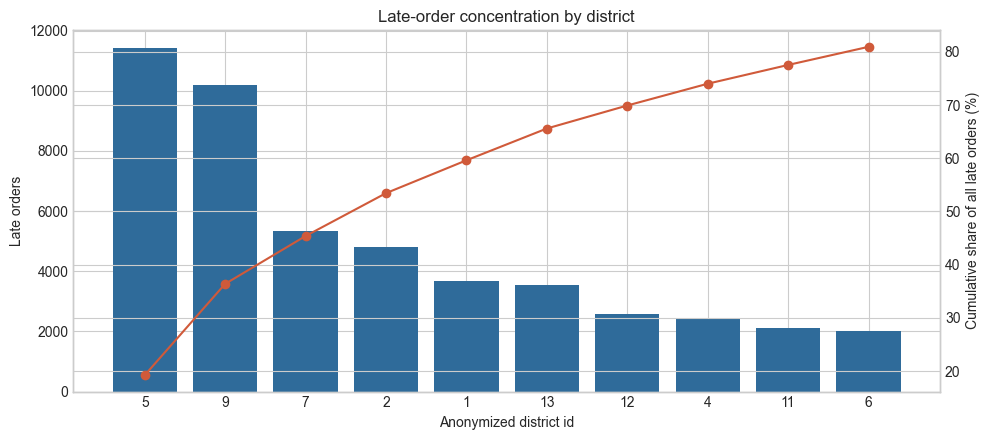

In [8]:
top = district_view.head(10)
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax2 = ax1.twinx()
ax1.bar(top["da_id"].astype(str), top["late_orders"], color="#2F6B9A")
ax2.plot(top["da_id"].astype(str), top["cumulative_late_share_pct"], color="#D05A3A", marker="o")
ax1.set_xlabel("Anonymized district id")
ax1.set_ylabel("Late orders")
ax2.set_ylabel("Cumulative share of all late orders (%)")
ax1.set_title("Late-order concentration by district")
fig.tight_layout()
plt.show()

商圈 5 和 9 合计贡献约 36.39% 的超时订单；前五个商圈以 48.52% 的订单贡献约 59.62% 的超时订单。因此增量资源不宜按照全城订单规模等比例配置；商圈优先级还需联合评估高峰暴露、履约阶段差异及实时候选运力，不能仅依据历史超时率形成资源配置结论。

## 6. 履约链路：阶段时长差异定位

In [9]:
stage_labels = {
    "order_to_push_minutes": "Order to dispatch-system entry",
    "order_push_to_accept_minutes": "Dispatch-system entry to acceptance",
    "accept_to_pickup_minutes": "Acceptance to pickup",
    "pickup_to_delivery_minutes": "Pickup to delivery",
}
stage_view = stage_gap.assign(stage_label=stage_gap["stage"].map(stage_labels))
stage_view[
    [
        "stage_label", "mean_on_time", "mean_late", "mean_gap_minutes", "gap_share",
        "p50_on_time", "p50_late", "p90_on_time", "p90_late",
    ]
]

,stage_label,mean_on_time,mean_late,mean_gap_minutes,gap_share,p50_on_time,p50_late,p90_on_time,p90_late
0,Order to dispatch-system entry,0.7853,1.4617,0.6764,0.0391,0.2000,0.2167,1.4667,3.6833
1,Dispatch-system entry to acceptance,2.9860,4.7958,1.8097,0.1045,1.5167,3.2667,7.1167,9.9500
2,Acceptance to pickup,9.5335,14.4762,4.9427,0.2854,8.6833,13.2333,16.7833,25.4167
3,Pickup to delivery,12.8618,22.7531,9.8913,0.5711,11.2333,22.1667,23.4167,36.7833


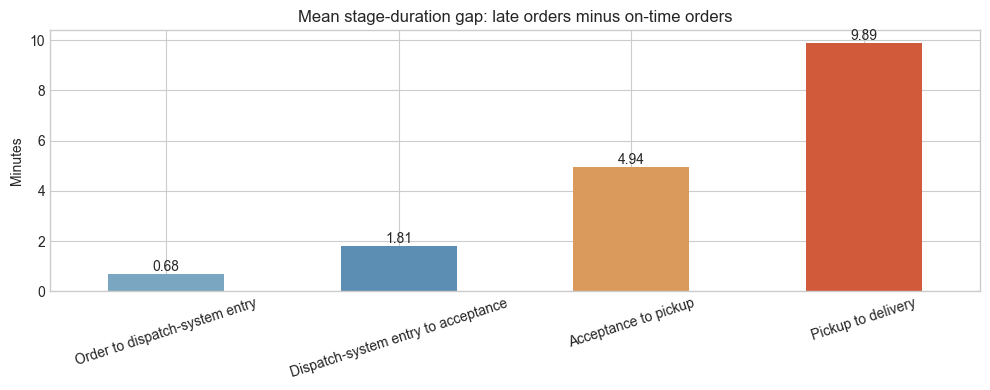

In [10]:
ax = stage_view.plot(
    x="stage_label", y="mean_gap_minutes", kind="bar", legend=False,
    figsize=(10, 4), color=["#7AA6C2", "#5B8EB2", "#D99A5B", "#D05A3A"]
)
ax.set_title("Mean stage-duration gap: late orders minus on-time orders")
ax.set_xlabel("")
ax.set_ylabel("Minutes")
ax.tick_params(axis="x", rotation=18)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.show()

这是一项可加总的**平均实际履约时长差异分解**：四阶段差异相加为 17.32 分钟。但它不是因果归因，也没有估计每阶段的计划预算。取餐后至送达差异最大，说明距离、路径、并单或负载值得优先验证；接单至取餐差异第二，但缺少到店时间，无法拆成去店路程和商家等待。

## 7. 订单复杂度：距离和派单尝试的梯度

In [11]:
strategy["distance_decile"] = pd.qcut(
    strategy["merchant_customer_distance_km"], 10, labels=False, duplicates="drop"
) + 1
distance_gradient = (
    strategy.groupby("distance_decile", observed=True)
    .agg(
        orders=("order_id", "size"),
        avg_distance_km=("merchant_customer_distance_km", "mean"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)
distance_gradient["late_rate_pct"] = distance_gradient["late_rate"] * 100
distance_gradient

,distance_decile,orders,avg_distance_km,late_rate,late_rate_pct
0,1,43607,0.2575,0.0582,5.8179
1,2,43606,0.5624,0.0735,7.3476
2,3,43606,0.8086,0.0957,9.5721
3,4,43606,1.0396,0.1124,11.2416
4,5,43606,1.2532,0.1341,13.4133
5,6,43606,1.4846,0.1514,15.1401
6,7,43606,1.7414,0.1658,16.5803
7,8,43606,2.0448,0.1786,17.8645
8,9,43606,2.4334,0.1901,19.0134
9,10,43607,3.3966,0.2036,20.3568


In [12]:
strategy["attempt_bucket"] = strategy["waybill_attempt_count"].clip(upper=4).astype(str).replace({"4": "4+"})
attempt_gradient = (
    strategy.groupby("attempt_bucket", observed=True)
    .agg(orders=("order_id", "size"), late_rate=("is_late", "mean"))
    .reindex(["1", "2", "3", "4+"])
    .reset_index()
)
attempt_gradient["late_rate_pct"] = attempt_gradient["late_rate"] * 100
attempt_gradient

,attempt_bucket,orders,late_rate,late_rate_pct
0,1,400799,0.1287,12.8700
1,2,25645,0.2087,20.8657
2,3,6218,0.2464,24.6381
3,4+,3400,0.2912,29.1176


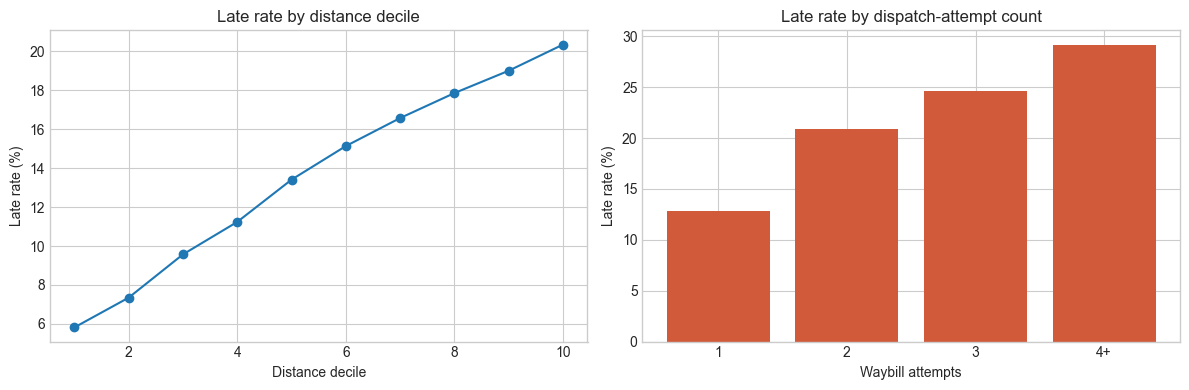

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(distance_gradient["distance_decile"], distance_gradient["late_rate_pct"], marker="o")
axes[0].set_title("Late rate by distance decile")
axes[0].set_xlabel("Distance decile")
axes[0].set_ylabel("Late rate (%)")

axes[1].bar(attempt_gradient["attempt_bucket"], attempt_gradient["late_rate_pct"], color="#D05A3A")
axes[1].set_title("Late rate by dispatch-attempt count")
axes[1].set_xlabel("Waybill attempts")
axes[1].set_ylabel("Late rate (%)")
plt.tight_layout()
plt.show()

距离和派单尝试次数与超时率均呈明显梯度，可用于风险分层：长距离订单需进一步评估服务半径、承诺时长与派单优先级；多次派单订单可作为调度摩擦的过程预警信号。但在形成经营结论前，仍需控制商圈、时段与承诺时长等混杂因素。

## 8. 供给口径审查：接单骑手数不等同于可用运力

In [14]:
cell = pd.read_parquet(METRICS / "district_date_slot_kpi.parquet")
rows = []
for minimum_orders in [10, 20, 30, 50, 100]:
    stable = cell.loc[cell["orders"].ge(minimum_orders)]
    rows.append({
        "minimum_orders": minimum_orders,
        "cells": len(stable),
        "spearman_activity_proxy_vs_late_rate": spearmanr(
            stable["orders_per_accepting_courier_proxy"], stable["late_rate"]
        ).statistic,
        "spearman_volume_vs_late_rate": spearmanr(stable["orders"], stable["late_rate"]).statistic,
    })
pd.DataFrame(rows)

,minimum_orders,cells,spearman_activity_proxy_vs_late_rate,spearman_volume_vs_late_rate
0,10,5422,0.1229,0.2649
1,20,4393,0.0959,0.2387
2,30,3681,0.0797,0.2222
3,50,2498,0.0267,0.2347
4,100,1348,-0.0391,0.2106


`orders / accepting_couriers` 只统计已经接过单的骑手，是结果内生的活动指标，不等于候选供给。它与超时率的秩相关对最小样本阈值很敏感，不能作为“缺骑手导致超时”的核心证据。真正的高峰供需诊断应使用 24 个官方候选骑手快照，并明确只能覆盖午高峰有限时点。

## 9. 诊断结论与后续分析计划

**已验证：** 超时在用餐高峰、部分匿名商圈、长距离和多次派单订单中更集中；超时单的主要实际时长差异出现在取餐后送达和接单至取餐阶段。

**较可能但尚未证实：** 部分高峰商圈存在供需失衡或骑手负载问题。

**无法由当前诊断证明：** 增加若干骑手会使准时率提高多少；接单至取餐慢是否主要由商家出餐导致。

下一步建立订单超时风险模型，采用按日期的跨期留出验证，并检查模型是否过度依赖商圈或日期模式；之后结合午高峰候选骑手快照开展包含资源约束的运力优先级离线回放。

## Sources

- `data/processed/order_fulfillment_mart.parquet`
- `outputs/metrics/*.csv`
- `outputs/metrics/district_date_slot_kpi.parquet`
- `scripts/build_metric_marts.py`